# Taller: Creación y Visualización de KPIs

## Sistema de información Gerencial (MIS) - QuickShop MiniMarket

**Materia:** Sistema de Información  

**Proyecto base (TPS):** TPS QuickShop  

**Fecha:** 29 de Mayo 2026  

**Integrantes:** Samuel Lucero, Gabriel Quilachamin

---


### Objetivo del Proyecto

Implementar un **Sistema de Información Gerencial (MIS)** que extraiga valor de los datos transaccionales de **MiniMarket QuickShop** y presente **KPIs** que respalden decisiones tácticas y estratégicas.





## Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
colors = sns.color_palette("husl", 10)



## Cargar y Explorar Datos del TPS

In [6]:
# Cargar datos del TPS
transacciones = pd.read_csv('transacciones.csv')
detalles_venta = pd.read_csv('detalles_venta.csv')
productos = pd.read_csv('productos.csv')
usuarios = pd.read_csv('usuarios.csv')
inventario = pd.read_csv('inventario.csv')

print("-" * 60)
print("EXPLORACIÓN INICIAL DE DATOS DEL TPS")
print("-" * 60)
print(f"\n1. Transacciones: {transacciones.shape}")
print(transacciones.head())
print(f"\n2. Detalles de Venta: {detalles_venta.shape}")
print(detalles_venta.head())
print(f"\n3. Productos: {productos.shape}")
print(f"\n4. Usuarios/Clientes: {usuarios.shape}")
print(f"\n5. Inventario: {inventario.shape}")

# Información de tipos de datos
print("\n" + "-" * 60)
print("TIPOS DE DATOS")
print("-" * 60)
print(transacciones.dtypes)

------------------------------------------------------------
EXPLORACIÓN INICIAL DE DATOS DEL TPS
------------------------------------------------------------

1. Transacciones: (286, 12)
  id_transaccion       fecha      hora     cajero  cedula_cliente  \
0        TX-0001  2025-05-11  17:49:53  Cajero_01       101262382   
1        TX-0002  2025-05-12  10:23:22  Cajero_01      1017351517   
2        TX-0003  2025-05-12  13:01:27  Cajero_01       430649691   
3        TX-0004  2025-05-13  13:24:20  Cajero_01      1548468772   
4        TX-0005  2025-05-14  08:27:24  Cajero_01       209800873   

             nombre_cliente  subtotal   iva  total    metodo_pago      estado  \
0      Diana Herrera Vargas       3.9  0.47   4.37  Transferencia  COMPLETADA   
1   Veronica Torres Morales      12.8  1.54  14.34             QR  COMPLETADA   
2      Andres Perez Pacheco       8.9  1.07   9.97       Efectivo  COMPLETADA   
3     Marco Guerrero Rivera      12.3  1.48  13.78       Efectivo  COMPLE

## Limpieza y Transformación de Datos

In [9]:
# Transformación de datos
print("-" * 60)
print("LIMPIEZA Y TRANSFORMACIÓN DE DATOS")
print("-" * 60)

# 1. Convertir fechas a datetime
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'])
usuarios['fecha_registro'] = pd.to_datetime(usuarios['fecha_registro'])

# 2. Crear columnas derivadas en transacciones
transacciones['año'] = transacciones['fecha'].dt.year
transacciones['mes'] = transacciones['fecha'].dt.month
transacciones['mes_nombre'] = transacciones['fecha'].dt.strftime('%B')
transacciones['día_semana'] = transacciones['fecha'].dt.day_name()
transacciones['trimestre'] = transacciones['fecha'].dt.quarter
transacciones['semana'] = transacciones['fecha'].dt.isocalendar().week

# 3. Verificar valores nulos
print("\nValores nulos por columna:")
print(transacciones.isnull().sum())

# 4. Estadísticas descriptivas
print("\nEstadísticas de Ventas:")
print(transacciones[['subtotal', 'iva', 'total']].describe())

# 5. Merge de detalles con información de productos
detalles_venta = detalles_venta.merge(
    productos[['codigo', 'categoria']], 
    left_on='codigo_producto', 
    right_on='codigo', 
    how='left'
)

# 6. Merge de transacciones con detalles
ventas_completas = transacciones.merge(
    detalles_venta.groupby('id_transaccion').agg({
        'cantidad': 'sum',
        'subtotal_linea': 'sum',
        'categoria': lambda x: list(set(x))
    }).reset_index(),
    left_on='id_transaccion',
    right_on='id_transaccion',
    how='left'
)


print(f"Dataset final: {ventas_completas.shape}")


------------------------------------------------------------
LIMPIEZA Y TRANSFORMACIÓN DE DATOS
------------------------------------------------------------

Valores nulos por columna:
id_transaccion    0
fecha             0
hora              0
cajero            0
cedula_cliente    0
nombre_cliente    0
subtotal          0
iva               0
total             0
metodo_pago       0
estado            0
valida_hasta      0
año               0
mes               0
mes_nombre        0
día_semana        0
trimestre         0
semana            0
dtype: int64

Estadísticas de Ventas:
         subtotal         iva       total
count  286.000000  286.000000  286.000000
mean     8.844930    1.061399    9.906329
std      5.947321    0.713633    6.660950
min      0.500000    0.060000    0.560000
25%      4.200000    0.500000    4.700000
50%      7.950000    0.955000    8.905000
75%     12.300000    1.480000   13.780000
max     39.900000    4.790000   44.690000
Dataset final: (286, 21)


## Cálculo de KPIs Principales

In [11]:
print("-" * 60)
print("CÁLCULO DE 8 KPIs PRINCIPALES")
print("-" * 60)

# KPI 1: Ventas Totales
kpi_ventas_totales = transacciones['total'].sum()

# KPI 2: Ticket Promedio (Venta Media)
kpi_ticket_promedio = transacciones['total'].mean()

# KPI 3: Número de Transacciones
kpi_num_transacciones = len(transacciones)

# KPI 4: Ingresos por Categoría de Producto
ingresos_categoria = detalles_venta.groupby('categoria')['subtotal_linea'].sum().sort_values(ascending=False)

# KPI 5: Margen de Ganancia (aprox. 30% del total)
margen_ganancia_estimado = kpi_ventas_totales * 0.30  # Estimación estándar

# KPI 6: Método de Pago más usado
metodo_pago_uso = transacciones['metodo_pago'].value_counts()
kpi_metodo_pago_top = metodo_pago_uso.idxmax()

# KPI 7: Clientes únicos
kpi_clientes_unicos = transacciones['cedula_cliente'].nunique()

# KPI 8: Tasa de Crecimiento Mensual de Ventas
ventas_por_mes = transacciones.groupby('mes')['total'].sum()
if len(ventas_por_mes) > 1:
    tasa_crecimiento = ((ventas_por_mes.iloc[-1] - ventas_por_mes.iloc[0]) / ventas_por_mes.iloc[0] * 100)
else:
    tasa_crecimiento = 0

# Mostrar KPIs
print(f"\n1. VENTAS TOTALES:")
print(f"   ${kpi_ventas_totales:,.2f}")

print(f"\n2. TICKET PROMEDIO:")
print(f"   ${kpi_ticket_promedio:,.2f}")

print(f"\n3. NÚMERO DE TRANSACCIONES:")
print(f"   {kpi_num_transacciones:,} transacciones")

print(f"\n4. INGRESOS POR CATEGORÍA (Top 5):")
print(ingresos_categoria.head())

print(f"\n5. MARGEN DE GANANCIA ESTIMADO:")
print(f"   ${margen_ganancia_estimado:,.2f}")

print(f"\n6. MÉTODO DE PAGO MÁS USADO:")
print(f"   {kpi_metodo_pago_top}")
print("\n   Distribución de métodos de pago:")
print(metodo_pago_uso)

print(f"\n7. CLIENTES ÚNICOS:")
print(f"   {kpi_clientes_unicos} clientes")

print(f"\n8. TASA DE CRECIMIENTO MENSUAL:")
print(f"   {tasa_crecimiento:.2f}%")

# Crear DataFrame de KPIs para referencia
kpis_df = pd.DataFrame({
    'KPI': ['Ventas Totales', 'Ticket Promedio', 'Transacciones', 'Margen Ganancia Est.', 'Clientes Únicos', 'Crecimiento Mensual (%)'],
    'Valor': [f'${kpi_ventas_totales:,.2f}', f'${kpi_ticket_promedio:,.2f}', f'{kpi_num_transacciones:,}', f'${margen_ganancia_estimado:,.2f}', f'{kpi_clientes_unicos}', f'{tasa_crecimiento:.2f}%']
})

print("\n" + "-" * 60)
print("RESUMEN DE KPIs")
print("-" * 60)
print(kpis_df.to_string(index=False))


------------------------------------------------------------
CÁLCULO DE 8 KPIs PRINCIPALES
------------------------------------------------------------

1. VENTAS TOTALES:
   $2,833.21

2. TICKET PROMEDIO:
   $9.91

3. NÚMERO DE TRANSACCIONES:
   286 transacciones

4. INGRESOS POR CATEGORÍA (Top 5):
categoria
Limpieza     448.00
Personal     390.00
Abarrotes    333.00
Lacteos      310.15
Bebidas      276.50
Name: subtotal_linea, dtype: float64

5. MARGEN DE GANANCIA ESTIMADO:
   $849.96

6. MÉTODO DE PAGO MÁS USADO:
   Efectivo

   Distribución de métodos de pago:
metodo_pago
Efectivo         150
Transferencia     46
QR                46
Tarjeta           44
Name: count, dtype: int64

7. CLIENTES ÚNICOS:
   97 clientes

8. TASA DE CRECIMIENTO MENSUAL:
   17.77%

------------------------------------------------------------
RESUMEN DE KPIs
------------------------------------------------------------
                    KPI     Valor
         Ventas Totales $2,833.21
        Ticket Promed

## Análisis de Productos Estrella

In [12]:
print("-" * 60)
print("ANÁLISIS DE PRODUCTOS ESTRELLA")
print("-" * 60)

# Top 5 productos por ingresos
top_productos_ingresos = detalles_venta.groupby('nombre_producto').agg({
    'subtotal_linea': 'sum',
    'cantidad': 'sum',
    'precio_unitario': 'first'
}).sort_values('subtotal_linea', ascending=False).head(5)

top_productos_ingresos['margen_estimado'] = top_productos_ingresos['subtotal_linea'] * 0.30
top_productos_ingresos.columns = ['Ingresos', 'Unidades', 'Precio Unitario', 'Margen Est.']

print("\nTop 5 Productos por INGRESOS:")
print(top_productos_ingresos)

# Top 5 productos por unidades
top_productos_unidades = detalles_venta.groupby('nombre_producto').agg({
    'cantidad': 'sum',
    'subtotal_linea': 'sum',
    'precio_unitario': 'first'
}).sort_values('cantidad', ascending=False).head(5)

top_productos_unidades.columns = ['Unidades', 'Ingresos', 'Precio Unitario']

print("\nTop 5 Productos por UNIDADES VENDIDAS:")
print(top_productos_unidades)

# Contribución al total de ventas
producto_contribucion = detalles_venta.groupby('nombre_producto')['subtotal_linea'].sum()
total_ventas = producto_contribucion.sum()
producto_contribucion_pct = (producto_contribucion / total_ventas * 100).sort_values(ascending=False)

print("\nTop 10 Productos por CONTRIBUCIÓN AL TOTAL DE VENTAS:")
print(producto_contribucion_pct.head(10))

# Productos por categoría
print("\nINGRESOS POR CATEGORÍA:")
ingresos_cat = detalles_venta.groupby('categoria').agg({
    'subtotal_linea': 'sum',
    'cantidad': 'sum'
}).sort_values('subtotal_linea', ascending=False)
ingresos_cat.columns = ['Ingresos Totales', 'Unidades']
print(ingresos_cat)


------------------------------------------------------------
ANÁLISIS DE PRODUCTOS ESTRELLA
------------------------------------------------------------

Top 5 Productos por INGRESOS:
                         Ingresos  Unidades  Precio Unitario  Margen Est.
nombre_producto                                                          
Protector solar FPS50        63.0        14              4.5        18.90
Huevos x12                   52.5        21              2.5        15.75
Shampoo anticaspa 400ml      49.4        13              3.8        14.82
Papel higienico x24          45.0         5              9.0        13.50
Huevos x30                   42.0         7              6.0        12.60

Top 5 Productos por UNIDADES VENDIDAS:
                    Unidades  Ingresos  Precio Unitario
nombre_producto                                        
Yogur natural 200g        23     17.25             0.75
Huevos x12                21     52.50             2.50
Granola 200g              17     3

## Análisis de Clientes Top

In [13]:
print("-" * 60)
print("ANÁLISIS DE CLIENTES TOP")
print("-" * 60)

# Top 5 clientes por ingresos
top_clientes = transacciones.groupby(['cedula_cliente', 'nombre_cliente']).agg({
    'total': 'sum',
    'id_transaccion': 'count'
}).sort_values('total', ascending=False).head(5)

top_clientes.columns = ['Ingresos Totales', 'Frecuencia (Compras)']
top_clientes['Ticket Promedio'] = top_clientes['Ingresos Totales'] / top_clientes['Frecuencia (Compras)']

print("\nTop 5 CLIENTES por INGRESOS:")
print(top_clientes)

# Segmentación de clientes por valor
transacciones_cliente = transacciones.groupby('cedula_cliente').agg({
    'total': ['sum', 'count', 'mean']
}).reset_index()

transacciones_cliente.columns = ['cedula', 'total_gasto', 'num_compras', 'ticket_promedio']
transacciones_cliente['segmento'] = pd.cut(
    transacciones_cliente['total_gasto'],
    bins=[0, 50, 100, 500, float('inf')],
    labels=['Bajo', 'Medio', 'Alto', 'VIP']
)

print("\nSEGMENTACIÓN DE CLIENTES:")
print(transacciones_cliente.groupby('segmento').agg({
    'cedula': 'count',
    'total_gasto': ['sum', 'mean']
}))

# Clientes frecuentes (más de 1 compra)
clientes_frecuentes = transacciones_cliente[transacciones_cliente['num_compras'] > 1]
print(f"\nCLIENTES FRECUENTES (más de 1 compra):")
print(f"  Total de clientes frecuentes: {len(clientes_frecuentes)}")
print(f"  Ingresos de clientes frecuentes: ${clientes_frecuentes['total_gasto'].sum():,.2f}")
print(f"  Porcentaje del total: {len(clientes_frecuentes) / len(transacciones_cliente) * 100:.1f}%")


------------------------------------------------------------
ANÁLISIS DE CLIENTES TOP
------------------------------------------------------------

Top 5 CLIENTES por INGRESOS:
                                         Ingresos Totales  \
cedula_cliente nombre_cliente                               
2122710895     Gabriel Cabrera Gonzalez             99.46   
1938002392     Raul Garcia Carrillo                 87.35   
327563202      Camila Carrillo Torres               78.06   
1017351517     Veronica Torres Morales              77.56   
209800873      Luis Miguel Reyes Rivera             77.28   

                                         Frecuencia (Compras)  Ticket Promedio  
cedula_cliente nombre_cliente                                                   
2122710895     Gabriel Cabrera Gonzalez                     7        14.208571  
1938002392     Raul Garcia Carrillo                         5        17.470000  
327563202      Camila Carrillo Torres                       5        15

## Análisis de Desempeño de Vendedores/Cajeros

In [14]:
print("-" * 60)
print("DESEMPEÑO DE VENDEDORES/CAJEROS")
print("-" * 60)

# Análisis de rendimiento por cajero
desempeño_cajeros = transacciones.groupby('cajero').agg({
    'total': ['sum', 'count', 'mean'],
    'id_transaccion': 'count'
}).round(2)

desempeño_cajeros.columns = ['Ventas Totales', 'Num Transacciones', 'Ticket Promedio', 'Transacciones']
desempeño_cajeros = desempeño_cajeros[['Ventas Totales', 'Num Transacciones', 'Ticket Promedio']]

print("\nDESEMPEÑO DE CAJEROS:")
print(desempeño_cajeros.sort_values('Ventas Totales', ascending=False))

# Top cajero
top_cajero = desempeño_cajeros['Ventas Totales'].idxmax()
print(f"\nCAJERO TOP: {top_cajero}")
print(f"Ventas: ${desempeño_cajeros.loc[top_cajero, 'Ventas Totales']:,.2f}")

# Métodos de pago preferidos por cajero
print("\nMÉTODO DE PAGO PREFERIDO POR CAJERO:")
metodos_por_cajero = transacciones.groupby(['cajero', 'metodo_pago']).size().unstack(fill_value=0)
print(metodos_por_cajero)


------------------------------------------------------------
DESEMPEÑO DE VENDEDORES/CAJEROS
------------------------------------------------------------

DESEMPEÑO DE CAJEROS:
           Ventas Totales  Num Transacciones  Ticket Promedio
cajero                                                       
Cajero_01         2833.21                286             9.91

CAJERO TOP: Cajero_01
Ventas: $2,833.21

MÉTODO DE PAGO PREFERIDO POR CAJERO:
metodo_pago  Efectivo  QR  Tarjeta  Transferencia
cajero                                           
Cajero_01         150  46       44             46


## 8. Implementación de Dashboards con Visualizaciones

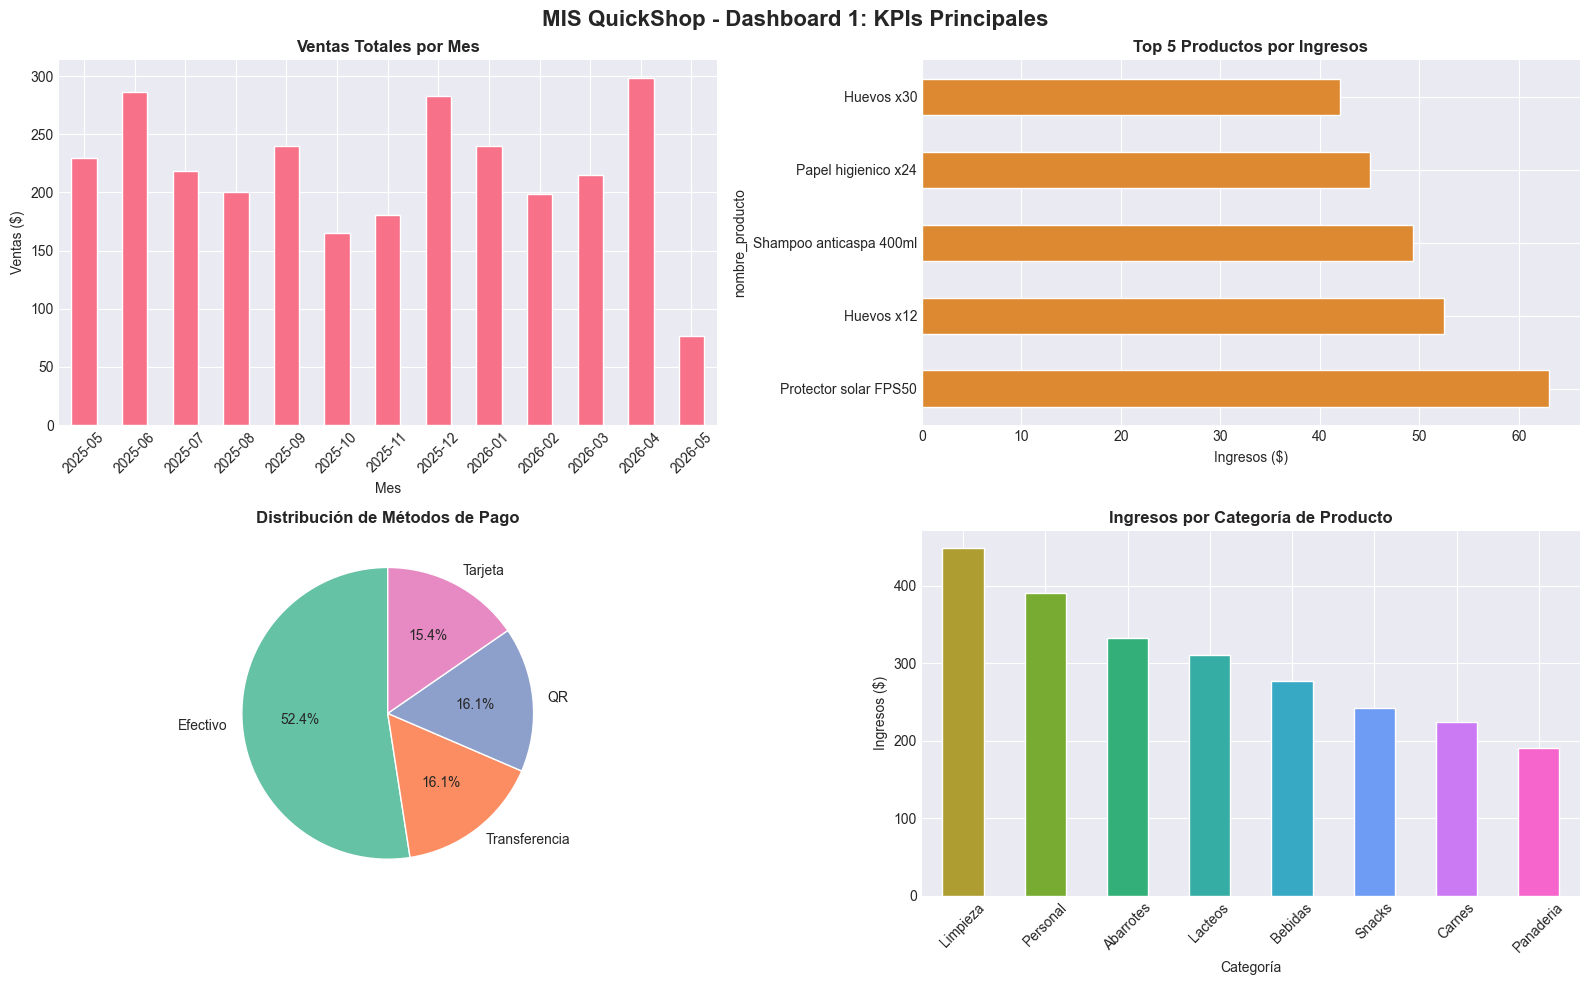

In [17]:


# Configurar tema
plt.style.use('seaborn-v0_8-darkgrid')
colors_palette = sns.color_palette("husl", 10)

# ==================== DASHBOARD 1: KPIs PRINCIPALES ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MIS QuickShop - Dashboard 1: KPIs Principales', fontsize=16, fontweight='bold')

# KPI 1: Ventas por mes
ax1 = axes[0, 0]
ventas_mes = transacciones.groupby(transacciones['fecha'].dt.to_period('M'))['total'].sum()
ventas_mes.index = ventas_mes.index.strftime('%Y-%m')
ventas_mes.plot(kind='bar', ax=ax1, color=colors_palette[0])
ax1.set_title('Ventas Totales por Mes', fontweight='bold')
ax1.set_ylabel('Ventas ($)')
ax1.set_xlabel('Mes')
ax1.tick_params(axis='x', rotation=45)

# KPI 2: Top 5 Productos
ax2 = axes[0, 1]
top_prod = detalles_venta.groupby('nombre_producto')['subtotal_linea'].sum().nlargest(5)
top_prod.plot(kind='barh', ax=ax2, color=colors_palette[1])
ax2.set_title('Top 5 Productos por Ingresos', fontweight='bold')
ax2.set_xlabel('Ingresos ($)')

# KPI 3: Métodos de Pago
ax3 = axes[1, 0]
metodos = transacciones['metodo_pago'].value_counts()
colors_pie = sns.color_palette("Set2", len(metodos))
ax3.pie(metodos, labels=metodos.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax3.set_title('Distribución de Métodos de Pago', fontweight='bold')

# KPI 4: Ingresos por Categoría
ax4 = axes[1, 1]
ing_cat = detalles_venta.groupby('categoria')['subtotal_linea'].sum().sort_values(ascending=False).head(8)
ing_cat.plot(kind='bar', ax=ax4, color=colors_palette[2:10])
ax4.set_title('Ingresos por Categoría de Producto', fontweight='bold')
ax4.set_ylabel('Ingresos ($)')
ax4.set_xlabel('Categoría')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Dashboard_1_KPIs_Principales.png', dpi=300, bbox_inches='tight')
plt.show()



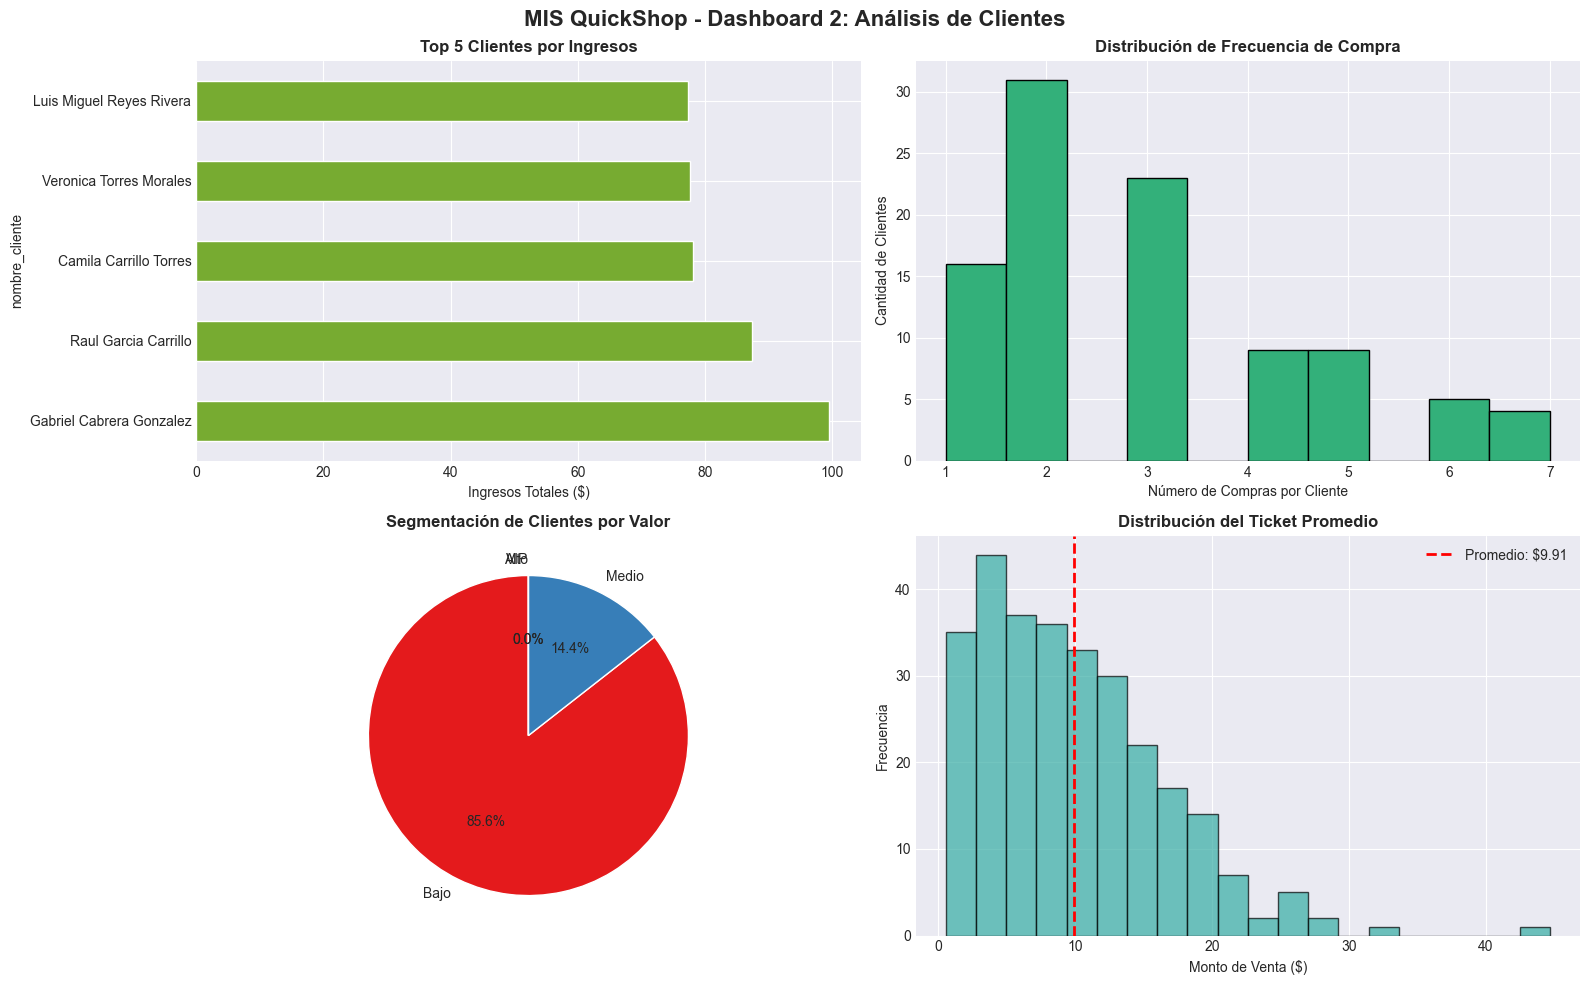

In [18]:
# ==================== DASHBOARD 2: ANÁLISIS DE CLIENTES ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MIS QuickShop - Dashboard 2: Análisis de Clientes', fontsize=16, fontweight='bold')

# Gráfico 1: Top 5 clientes
ax1 = axes[0, 0]
top_5_clientes = transacciones.groupby('nombre_cliente')['total'].sum().nlargest(5)
top_5_clientes.plot(kind='barh', ax=ax1, color=colors_palette[3])
ax1.set_title('Top 5 Clientes por Ingresos', fontweight='bold')
ax1.set_xlabel('Ingresos Totales ($)')

# Gráfico 2: Frecuencia de compra
ax2 = axes[0, 1]
freq_compras = transacciones.groupby('cedula_cliente').size()
ax2.hist(freq_compras, bins=10, color=colors_palette[4], edgecolor='black')
ax2.set_title('Distribución de Frecuencia de Compra', fontweight='bold')
ax2.set_xlabel('Número de Compras por Cliente')
ax2.set_ylabel('Cantidad de Clientes')

# Gráfico 3: Segmentación de Clientes
ax3 = axes[1, 0]
segmentos = transacciones_cliente['segmento'].value_counts()
colors_seg = sns.color_palette("Set1", len(segmentos))
ax3.pie(segmentos, labels=segmentos.index, autopct='%1.1f%%', colors=colors_seg, startangle=90)
ax3.set_title('Segmentación de Clientes por Valor', fontweight='bold')

# Gráfico 4: Distribución de ticket promedio
ax4 = axes[1, 1]
ticket_dist = transacciones['total'].values
ax4.hist(ticket_dist, bins=20, color=colors_palette[5], edgecolor='black', alpha=0.7)
ax4.axvline(kpi_ticket_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${kpi_ticket_promedio:.2f}')
ax4.set_title('Distribución del Ticket Promedio', fontweight='bold')
ax4.set_xlabel('Monto de Venta ($)')
ax4.set_ylabel('Frecuencia')
ax4.legend()

plt.tight_layout()
plt.savefig('Dashboard_2_Analisis_Clientes.png', dpi=300, bbox_inches='tight')
plt.show()




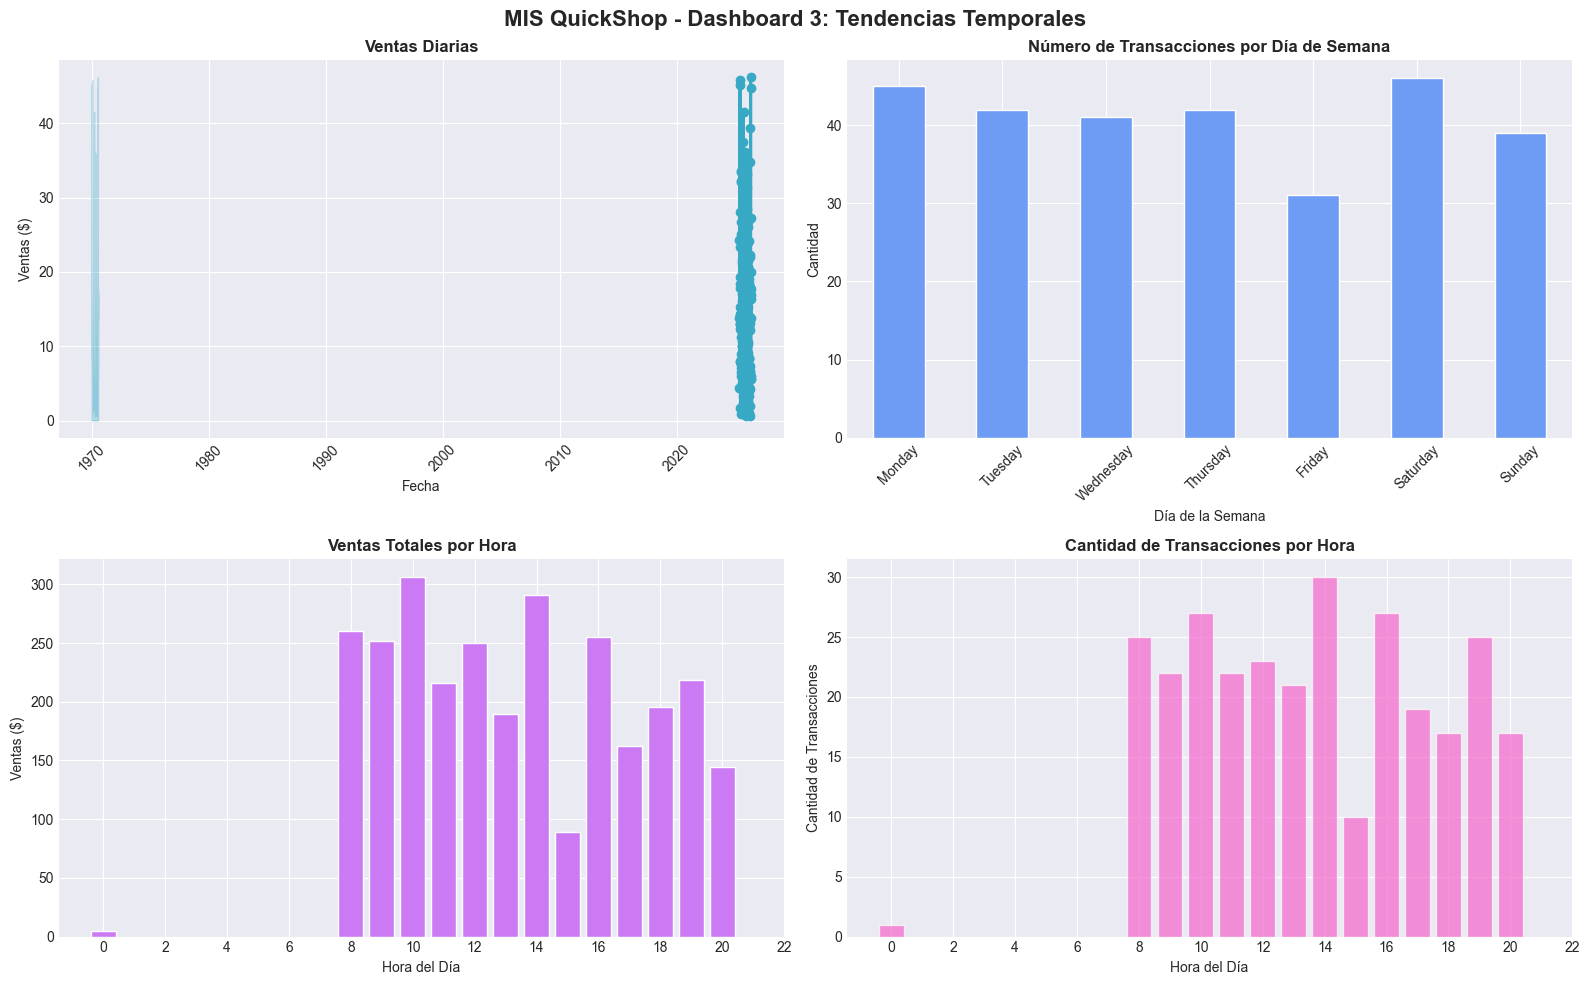

In [19]:
# ==================== DASHBOARD 3: TENDENCIAS Y PRONÓSTICOS ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MIS QuickShop - Dashboard 3: Tendencias Temporales', fontsize=16, fontweight='bold')

# Gráfico 1: Ventas por día
ax1 = axes[0, 0]
ventas_dia = transacciones.groupby(transacciones['fecha'].dt.date)['total'].sum()
ax1.plot(ventas_dia.index, ventas_dia.values, marker='o', color=colors_palette[6], linewidth=2)
ax1.fill_between(range(len(ventas_dia)), ventas_dia.values, alpha=0.3, color=colors_palette[6])
ax1.set_title('Ventas Diarias', fontweight='bold')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Ventas ($)')
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Transacciones por día de la semana
ax2 = axes[0, 1]
dia_semana_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trans_dia_semana = transacciones.groupby('día_semana').size().reindex(dia_semana_orden, fill_value=0)
trans_dia_semana.plot(kind='bar', ax=ax2, color=colors_palette[7])
ax2.set_title('Número de Transacciones por Día de Semana', fontweight='bold')
ax2.set_ylabel('Cantidad')
ax2.set_xlabel('Día de la Semana')
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3: Ventas por hora (aproximado)
ax3 = axes[1, 0]
transacciones['hora'] = pd.to_datetime(transacciones['hora'], format='%H:%M:%S').dt.hour
ventas_hora = transacciones.groupby('hora')['total'].agg(['sum', 'count'])
ax3.bar(ventas_hora.index, ventas_hora['sum'], color=colors_palette[8])
ax3.set_title('Ventas Totales por Hora', fontweight='bold')
ax3.set_xlabel('Hora del Día')
ax3.set_ylabel('Ventas ($)')
ax3.set_xticks(range(0, 24, 2))

# Gráfico 4: Cantidad de transacciones por hora
ax4 = axes[1, 1]
ax4.bar(ventas_hora.index, ventas_hora['count'], color=colors_palette[9], alpha=0.7)
ax4.set_title('Cantidad de Transacciones por Hora', fontweight='bold')
ax4.set_xlabel('Hora del Día')
ax4.set_ylabel('Cantidad de Transacciones')
ax4.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('Dashboard_3_Tendencias_Temporales.png', dpi=300, bbox_inches='tight')
plt.show()



## Generación de Reportes Programados

In [22]:
print("-" * 60)
print("REPORTES PROGRAMADOS:")
print("-" * 60)

# Obtener fecha máxima de los datos
fecha_max = transacciones['fecha'].max()
fecha_min = transacciones['fecha'].min()

# REPORTE 1: Ventas del Día Anterior
print("\n" + "-" * 60)
print("REPORTE: VENTAS DEL DÍA ANTERIOR")
print("-" * 60)

# Asumir el día anterior como el último día en los datos
ventas_ultimo_dia = transacciones[transacciones['fecha'] == fecha_max]
print(f"\nFecha: {fecha_max.strftime('%d de %B de %Y')}")
print(f"  Total de transacciones: {len(ventas_ultimo_dia)}")
print(f"  Ventas totales: ${ventas_ultimo_dia['total'].sum():,.2f}")
print(f"  Ticket promedio: ${ventas_ultimo_dia['total'].mean():,.2f}")
print(f"  Mayor venta: ${ventas_ultimo_dia['total'].max():,.2f}")
print(f"  Menor venta: ${ventas_ultimo_dia['total'].min():,.2f}")

# REPORTE 2: Ventas de la Semana
print("\n" + "-" * 60)
print("REPORTE: VENTAS DE LA SEMANA ACTUAL")
print("-" * 60)

semana_actual = transacciones[
    (transacciones['fecha'] >= fecha_max - timedelta(days=7)) &
    (transacciones['fecha'] <= fecha_max)
]
ventas_por_dia_semana = semana_actual.groupby(semana_actual['fecha'].dt.date).agg({
    'total': ['sum', 'count', 'mean']
})

print(f"\nPeríodo: {(fecha_max - timedelta(days=7)).strftime('%d/%m')} - {fecha_max.strftime('%d/%m/%Y')}")
print(f"  Total de transacciones: {len(semana_actual)}")
print(f"  Ventas totales semana: ${semana_actual['total'].sum():,.2f}")
print(f"  Promedio diario: ${semana_actual['total'].sum() / 7:,.2f}")
print("\n  Detalle diario:")
print(ventas_por_dia_semana)

# REPORTE 3: Ventas del Mes
print("\n" + "-" * 60)
print("REPORTE: VENTAS DEL MES ACTUAL")
print("-" * 60)

mes_actual = transacciones[transacciones['fecha'].dt.to_period('M') == fecha_max.to_period('M')]
print(f"\nMes: {fecha_max.strftime('%B de %Y')}")
print(f"  Total de transacciones: {len(mes_actual)}")
print(f"  Ventas totales mes: ${mes_actual['total'].sum():,.2f}")
print(f"  Promedio diario: ${mes_actual['total'].sum() / len(mes_actual.groupby(mes_actual['fecha'].dt.date)):,.2f}")
print(f"  Ticket promedio: ${mes_actual['total'].mean():,.2f}")

# Productos más vendidos este mes
print("\n  Productos TOP 5 del mes:")
prod_mes = detalles_venta.merge(
    transacciones[['id_transaccion', 'fecha']], 
    left_on='id_transaccion', 
    right_on='id_transaccion'
)
prod_mes = prod_mes[prod_mes['fecha'].dt.to_period('M') == fecha_max.to_period('M')]
top_prod_mes = prod_mes.groupby('nombre_producto')['subtotal_linea'].sum().nlargest(5)
for i, (prod, monto) in enumerate(top_prod_mes.items(), 1):
    print(f"    {i}. {prod}: ${monto:,.2f}")


------------------------------------------------------------
REPORTES PROGRAMADOS:
------------------------------------------------------------

------------------------------------------------------------
REPORTE: VENTAS DEL DÍA ANTERIOR
------------------------------------------------------------

Fecha: 12 de May de 2026
  Total de transacciones: 6
  Ventas totales: $17.75
  Ticket promedio: $2.96
  Mayor venta: $6.16
  Menor venta: $1.01

------------------------------------------------------------
REPORTE: VENTAS DE LA SEMANA ACTUAL
------------------------------------------------------------

Período: 05/05 - 12/05/2026
  Total de transacciones: 9
  Ventas totales semana: $54.49
  Promedio diario: $7.78

  Detalle diario:
            total                 
              sum count       mean
fecha                             
2026-05-05   6.05     1   6.050000
2026-05-07  16.91     1  16.910000
2026-05-08  13.78     1  13.780000
2026-05-12  17.75     6   2.958333

----------------

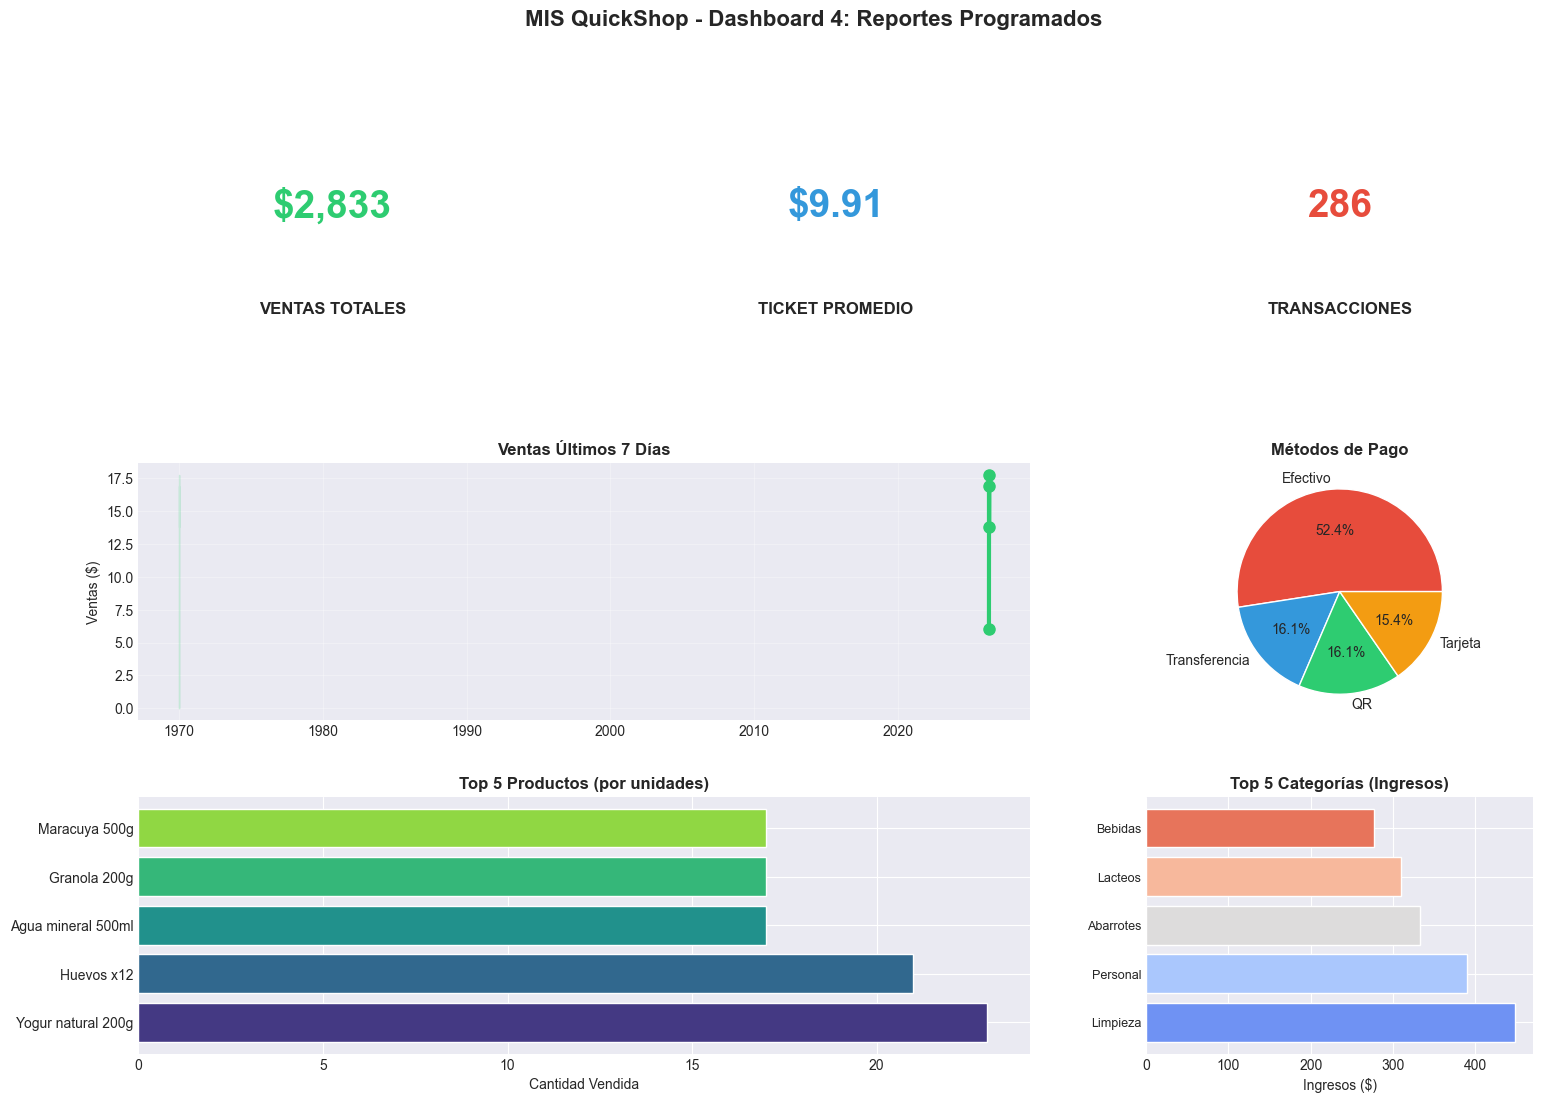

In [23]:
# ==================== DASHBOARD 4: REPORTES PROGRAMADOS ====================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
fig.suptitle('MIS QuickShop - Dashboard 4: Reportes Programados', fontsize=16, fontweight='bold')

# Tarjetas de KPI
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi1.text(0.5, 0.7, f'${kpi_ventas_totales:,.0f}', ha='center', va='center', fontsize=28, fontweight='bold', color='#2ecc71')
ax_kpi1.text(0.5, 0.3, 'VENTAS TOTALES', ha='center', va='center', fontsize=12, fontweight='bold')
ax_kpi1.set_xlim(0, 1)
ax_kpi1.set_ylim(0, 1)
ax_kpi1.axis('off')
ax_kpi1.patch.set_facecolor('#f0f0f0')

ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi2.text(0.5, 0.7, f'${kpi_ticket_promedio:,.2f}', ha='center', va='center', fontsize=28, fontweight='bold', color='#3498db')
ax_kpi2.text(0.5, 0.3, 'TICKET PROMEDIO', ha='center', va='center', fontsize=12, fontweight='bold')
ax_kpi2.set_xlim(0, 1)
ax_kpi2.set_ylim(0, 1)
ax_kpi2.axis('off')
ax_kpi2.patch.set_facecolor('#f0f0f0')

ax_kpi3 = fig.add_subplot(gs[0, 2])
ax_kpi3.text(0.5, 0.7, f'{kpi_num_transacciones:,}', ha='center', va='center', fontsize=28, fontweight='bold', color='#e74c3c')
ax_kpi3.text(0.5, 0.3, 'TRANSACCIONES', ha='center', va='center', fontsize=12, fontweight='bold')
ax_kpi3.set_xlim(0, 1)
ax_kpi3.set_ylim(0, 1)
ax_kpi3.axis('off')
ax_kpi3.patch.set_facecolor('#f0f0f0')

# Gráfico: Ventas últimos 7 días
ax1 = fig.add_subplot(gs[1, :2])
ventas_7dias = transacciones[transacciones['fecha'] >= fecha_max - timedelta(days=7)].groupby(
    transacciones['fecha'].dt.date
)['total'].sum()
ax1.plot(ventas_7dias.index, ventas_7dias.values, marker='o', color='#2ecc71', linewidth=3, markersize=8)
ax1.fill_between(range(len(ventas_7dias)), ventas_7dias.values, alpha=0.2, color='#2ecc71')
ax1.set_title('Ventas Últimos 7 Días', fontweight='bold', fontsize=12)
ax1.set_ylabel('Ventas ($)')
ax1.grid(True, alpha=0.3)

# Métodos de pago
ax2 = fig.add_subplot(gs[1, 2])
metodos_count = transacciones['metodo_pago'].value_counts()
colors_methods = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
ax2.pie(metodos_count, labels=metodos_count.index, autopct='%1.1f%%', colors=colors_methods[:len(metodos_count)])
ax2.set_title('Métodos de Pago', fontweight='bold', fontsize=12)

# Top 5 productos
ax3 = fig.add_subplot(gs[2, :2])
top_5_prod = detalles_venta.groupby('nombre_producto')['cantidad'].sum().nlargest(5)
ax3.barh(range(len(top_5_prod)), top_5_prod.values, color=sns.color_palette("viridis", len(top_5_prod)))
ax3.set_yticks(range(len(top_5_prod)))
ax3.set_yticklabels(top_5_prod.index)
ax3.set_title('Top 5 Productos (por unidades)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Cantidad Vendida')

# Rendimiento de categorías
ax4 = fig.add_subplot(gs[2, 2])
cat_ing = detalles_venta.groupby('categoria')['subtotal_linea'].sum().nlargest(5)
ax4.barh(range(len(cat_ing)), cat_ing.values, color=sns.color_palette("coolwarm", len(cat_ing)))
ax4.set_yticks(range(len(cat_ing)))
ax4.set_yticklabels(cat_ing.index, fontsize=9)
ax4.set_title('Top 5 Categorías (Ingresos)', fontweight='bold', fontsize=12)
ax4.set_xlabel('Ingresos ($)')

plt.savefig('Dashboard_4_Reportes_Programados.png', dpi=300, bbox_inches='tight')
plt.show()
